# Cross-Dataset Feasibility Audit

Phase-1 audit from `docs/constraint_evaluation_guidance.md` §5. For each of
LCLD / CCFD / IEEE-CIS / Sparkov, trains a neural model, runs unconstrained
CAPGD on the full test set, and applies dataset-specific constraint checkers
to measure clean vs adversarial feasibility.

**Produces**
- `results/adv_examples/cross_dataset_feasibility/{dataset}_neural_unmasked_seed{s}.parquet`
- `cross_dataset_feasibility_results.csv` — per-(dataset, seed) feasibility + metrics
- `cross_dataset_feasibility_gradient.csv` — mean ± std per dataset, the §4 gradient table
- `gradient.png` — bar chart of adversarial feasibility rate by dataset

**Scope**: 4 datasets × 3 seeds × ε=0.1. Single-seed stats in the existing
mask-ablation results (`mask_ablation_findings.md`) are superseded for LCLD by
the seed-averaged row produced here.

**Bootstrap cells (1–5) mirror `notebooks/mask_ablation.ipynb` verbatim** —
Drive mount, repo clone, deps install (requires runtime restart), dataset
symlinks.


In [1]:
# Cell 1: Verify GPU
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_mem = getattr(props, "total_memory", getattr(props, "total_mem", 0)) / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU")


GPU: NVIDIA A100-SXM4-40GB (42.4 GB)


In [2]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = "/content/drive/MyDrive/FraudBench"
for subdir in ["data", "results", "results/adv_examples"]:
    os.makedirs(os.path.join(DRIVE_ROOT, subdir), exist_ok=True)
print("Google Drive mounted.")


Mounted at /content/drive
Google Drive mounted.


In [3]:
# Cell 3: Clone or update repo
import os, shutil

REPO_URL = "https://github.com/iHaydenzZ/Capstone_FraudBench.git"
REPO_DIR = "/content/Capstone_FraudBench"

if os.path.exists(os.path.join(REPO_DIR, ".git")):
    os.chdir(REPO_DIR)
    !git pull
else:
    os.chdir("/content")
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
    !git clone {REPO_URL} {REPO_DIR}
    os.chdir(REPO_DIR)

print(f"Working directory: {os.getcwd()}")
!git log --oneline -3


Cloning into '/content/Capstone_FraudBench'...
remote: Enumerating objects: 1009, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 1009 (delta 111), reused 116 (delta 59), pack-reused 839 (from 1)
Receiving objects: 100% (1009/1009), 3.10 MiB | 19.38 MiB/s, done.
Resolving deltas: 100% (649/649), done.
Working directory: /content/Capstone_FraudBench
d52208f (HEAD -> master, origin/master, origin/HEAD) fix(cross-dataset): add EVAL_TOL to g2/g3 + document two-tolerance convention
2fa5eba docs: propagate EVAL_TOL fix — LCLD M1+g1 now saturates at 100% FSR
326483d fix(g1-projection): add EVAL_TOL=1e-6 to g2/g3 to absorb round-trip drift


In [4]:
# Cell 4: Install dependencies
# Colab's pre-installed numpy/scipy can conflict with project deps.
# Force a compatible set, then restart the runtime so the C extensions reload.
!pip install "numpy<2.1" "scipy>=1.14,<1.15" "scikit-learn>=1.5" -q 2>&1 | tail -5
!pip install -e . --no-deps -q 2>&1 | tail -5
!pip install "numba>=0.61" -q 2>&1 | tail -3
!pip install xgboost torch art pyyaml joblib pandas matplotlib -q 2>&1 | tail -3

# --- IMPORTANT ---
# After this cell finishes, restart the runtime:
#   Runtime > Restart session  (or Ctrl+M then .)
# Then skip this cell and continue from Cell 5.
# The restart is needed because Colab caches numpy's C extensions in memory.
print("\n>>> RESTART THE RUNTIME NOW, then skip this cell and run from Cell 5. <<<")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 65.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.4/610.4 kB 17.5 MB/s eta 0:00:00

>>> RESTART THE RUNTIME NOW, then skip this cell and run from Cell 5. <<<


In [1]:
# Cell 5: Symlink datasets from Google Drive
import os

DRIVE_DATA = "/content/drive/MyDrive/FraudBench/data"
DATASETS_DIR = "/content/Capstone_FraudBench/datasets"

for dataset_dir in ["CCFD", "ieee-fraud-detection", "LCLD", "Sparkov"]:
    src = os.path.join(DRIVE_DATA, dataset_dir)
    dst = os.path.join(DATASETS_DIR, dataset_dir)
    if os.path.islink(dst):
        os.unlink(dst)
    if os.path.exists(src):
        os.symlink(src, dst)
        print(f"  Linked: {dataset_dir}/")
    else:
        print(f"  NOT FOUND: {dataset_dir}/ -- upload to {src}")

print("Dataset symlinks ready.")


  Linked: CCFD/
  Linked: ieee-fraud-detection/
  Linked: LCLD/
  Linked: Sparkov/
Dataset symlinks ready.


In [2]:
# Cell 6: Experiment configuration
import os
import numpy as np
import pandas as pd

# All four datasets, 3 seeds, unconstrained (no mask) CAPGD at eps=0.1.
DATASETS = ["lcld", "ccfd", "ieee_cis", "sparkov"]
SEEDS = [42, 123, 456]
EPSILON = 0.1
SAMPLE_FRAC = 0.1
ATTACK_PARAMS = {"epsilon": EPSILON, "steps": 10, "step_size": EPSILON / 4}
MODEL_PARAMS = {"epochs": 20, "hidden_dim": 128, "batch_size": 256, "lr": 0.001}

# Tolerances. G1_TOL is the LCLD installment-formula tolerance (raw dollars);
# TOL_OHE is the one-hot sum/max slack used by every OHE validity check;
# EVAL_TOL absorbs float64 round-trip drift on integer-valued count columns
# in the g2/g3 inequality checks (see docs/constraint_evaluation_guidance.md
# §9 for why two tolerance conventions coexist).
G1_TOL = 0.10
TOL_OHE = 0.01
EVAL_TOL = 1e-6

OUT_DIR = "results/adv_examples/cross_dataset_feasibility"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Output dir: {OUT_DIR}")
print(f"Plan: {len(DATASETS)} datasets x {len(SEEDS)} seeds = {len(DATASETS)*len(SEEDS)} runs")


Output dir: results/adv_examples/cross_dataset_feasibility
Plan: 4 datasets x 3 seeds = 12 runs


In [3]:
# Cell 7: Shared utilities
# Inverse-transform only the numeric branch of the preprocessor (OHE columns
# stay in processed space so OHE validity can be checked there).
import re

def _to_float(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    return pd.to_numeric(
        series.astype(str).str.replace(r"[^\d.\-]", "", regex=True),
        errors="coerce",
    )


def get_scaler_and_num_names(preprocessor):
    for name, transformer, columns in preprocessor.pipeline.transformers_:
        if name == "num":
            return transformer.named_steps["scaler"], list(columns)
    raise RuntimeError("No 'num' branch on the preprocessor")


def inverse_transform_numeric(X_proc, num_feature_names, scaler):
    sanitize = lambda c: re.sub(r"[\[\]<>]", "_", c)
    sanitized_num = [sanitize(c) for c in num_feature_names]
    proc_cols = X_proc.columns.tolist()
    matched = [(raw, san) for raw, san in zip(num_feature_names, sanitized_num)
               if san in proc_cols]
    if not matched:
        return pd.DataFrame(index=X_proc.index)
    raw_names = [m[0] for m in matched]
    san_names = [m[1] for m in matched]
    idx_in_scaler = [num_feature_names.index(r) for r in raw_names]
    X_scaled = X_proc[san_names].values
    means = scaler.mean_[idx_in_scaler]
    scales = scaler.scale_[idx_in_scaler]
    X_raw_vals = X_scaled * scales + means
    return pd.DataFrame(X_raw_vals, columns=raw_names, index=X_proc.index)


def check_ohe_valid(X_proc, raw_prefix, tol=TOL_OHE):
    '''Generic OHE validity — among columns prefixed by raw_prefix+'_', require
    sum~1 and max~1. Returns pass Series, or None if no such columns exist.'''
    cols = [c for c in X_proc.columns if c.startswith(raw_prefix + "_")]
    if not cols:
        return None
    ohe = X_proc[cols].values
    row_sum = ohe.sum(axis=1)
    row_max = ohe.max(axis=1)
    valid = (np.abs(row_sum - 1.0) < tol) & (np.abs(row_max - 1.0) < tol)
    return pd.Series(valid, index=X_proc.index)


def pass_rate(series):
    return float(series.fillna(True).mean()) if series is not None else np.nan


def _bool_series(series_or_none, index, default_true=True):
    '''Coerce an optional Series to bool with NaN->True (so missing constraints
    do not penalize aggregate feasibility). Returns a Series over `index`.'''
    if series_or_none is None:
        return pd.Series(default_true, index=index)
    return series_or_none.fillna(True).astype(bool)


In [4]:
# Cell 8: LCLD constraint checkers (g1-g4 + aggregate)
# g1 is the installment amortisation formula — the known dominant bottleneck
# (tabularbench_comparison_findings.md: ~0.9-2.0% adv pass rate).

def reconstruct_term_from_ohe(X_proc):
    term_cols = [c for c in X_proc.columns if c.startswith("term_")]
    if not term_cols:
        return None
    term_vals = {}
    for col in term_cols:
        val = pd.to_numeric(
            col.replace("term_", "").replace("months", "").strip(),
            errors="coerce",
        )
        if not np.isnan(val):
            term_vals[col] = val
    if not term_vals:
        return None
    term_df = X_proc[list(term_vals.keys())]
    best_col = term_df.idxmax(axis=1)
    return best_col.map(term_vals)


def check_g1_installment(df, tol=G1_TOL):
    '''installment = loan_amnt * r * (1+r)^t / ((1+r)^t - 1), r = int_rate/1200.'''
    needed = {"loan_amnt", "int_rate", "term", "installment"}
    if not needed.issubset(df.columns):
        return None
    loan = _to_float(df["loan_amnt"])
    rate = _to_float(df["int_rate"])
    term = _to_float(df["term"])
    inst = _to_float(df["installment"])
    r = rate / 12.0 / 100.0
    with np.errstate(divide="ignore", invalid="ignore"):
        expected = loan * r * (1 + r) ** term / ((1 + r) ** term - 1)
    return (inst - expected).abs() < tol


def check_g2_open_total(df, tol=EVAL_TOL):
    if not {"open_acc", "total_acc"}.issubset(df.columns):
        return None
    return _to_float(df["open_acc"]) <= _to_float(df["total_acc"]) + tol


def check_g3_bankruptcies(df, tol=EVAL_TOL):
    if not {"pub_rec_bankruptcies", "pub_rec"}.issubset(df.columns):
        return None
    return _to_float(df["pub_rec_bankruptcies"]) <= _to_float(df["pub_rec"]) + tol


def check_g4_term_ohe(X_proc):
    return check_ohe_valid(X_proc, "term", tol=TOL_OHE)


def lcld_feasibility(X_raw, X_proc):
    X_raw = X_raw.copy()
    term = reconstruct_term_from_ohe(X_proc)
    if term is not None:
        X_raw["term"] = term.values
    per = {
        "g1_installment": pass_rate(check_g1_installment(X_raw)),
        "g2_open_total":  pass_rate(check_g2_open_total(X_raw)),
        "g3_bankruptcy":  pass_rate(check_g3_bankruptcies(X_raw)),
        "g4_term_ohe":    pass_rate(check_g4_term_ohe(X_proc)),
    }
    g1 = _bool_series(check_g1_installment(X_raw), X_raw.index)
    g2 = _bool_series(check_g2_open_total(X_raw),  X_raw.index)
    g3 = _bool_series(check_g3_bankruptcies(X_raw), X_raw.index)
    g4 = _bool_series(check_g4_term_ohe(X_proc),   X_raw.index)
    agg = float((g1 & g2 & g3 & g4).mean())
    return per, agg


In [5]:
# Cell 9: Sparkov constraint checkers
# Primary non-trivial check: continental-US bounding box on merchant lat/long.
# Guidance doc §3.4 flagged cardholder lat/long vs state/zip as geo-consistency,
# but those fields are immutable cardholder attributes (not attacker-controllable),
# so the interesting target is merchant location. Widely-used bbox below.
US_LAT_MIN, US_LAT_MAX = 24.5, 49.4
US_LON_MIN, US_LON_MAX = -125.0, -66.9


def check_amt_positive(df):
    if "amt" not in df.columns:
        return None
    return _to_float(df["amt"]) > 0


def check_city_pop_positive(df):
    if "city_pop" not in df.columns:
        return None
    return _to_float(df["city_pop"]) > 0


def check_merchant_bbox(df):
    if not {"merch_lat", "merch_long"}.issubset(df.columns):
        return None
    lat = _to_float(df["merch_lat"])
    lon = _to_float(df["merch_long"])
    return lat.between(US_LAT_MIN, US_LAT_MAX) & lon.between(US_LON_MIN, US_LON_MAX)


def sparkov_feasibility(X_raw, X_proc):
    per = {
        "s_amt_positive":   pass_rate(check_amt_positive(X_raw)),
        "s_city_pop_pos":   pass_rate(check_city_pop_positive(X_raw)),
        "s_merch_bbox":     pass_rate(check_merchant_bbox(X_raw)),
        "s_category_ohe":   pass_rate(check_ohe_valid(X_proc, "category")),
        "s_gender_ohe":     pass_rate(check_ohe_valid(X_proc, "gender")),
        "s_state_ohe":      pass_rate(check_ohe_valid(X_proc, "state")),
    }
    idx = X_raw.index
    parts = [
        _bool_series(check_amt_positive(X_raw),        idx),
        _bool_series(check_merchant_bbox(X_raw),       idx),
        _bool_series(check_ohe_valid(X_proc, "category"), idx),
        _bool_series(check_ohe_valid(X_proc, "gender"),   idx),
    ]
    agg_series = parts[0]
    for p in parts[1:]:
        agg_series = agg_series & p
    agg = float(agg_series.mean())
    return per, agg


In [6]:
# Cell 10: IEEE-CIS constraint checkers
# C1-C14 are documented counts (>= 0). D1-D15 are timedeltas (>= 0 in spirit,
# but may be NaN-encoded in raw data). Tol of -0.5 absorbs StandardScaler
# round-trip noise on true zeros.
C_PATTERN = re.compile(r"^C\d+$")
D_PATTERN = re.compile(r"^D\d+$")


def check_txn_amt_positive(df):
    if "TransactionAmt" not in df.columns:
        return None
    return _to_float(df["TransactionAmt"]) > 0


def check_c_nonneg(df):
    c_cols = [c for c in df.columns if C_PATTERN.match(c)]
    if not c_cols:
        return None
    vals = df[c_cols].apply(_to_float)
    return (vals >= -0.5).all(axis=1)


def check_d_nonneg(df):
    d_cols = [c for c in df.columns if D_PATTERN.match(c)]
    if not d_cols:
        return None
    vals = df[d_cols].apply(_to_float).fillna(0.0)
    return (vals >= -0.5).all(axis=1)


def ieee_feasibility(X_raw, X_proc):
    per = {
        "i_amt_positive":   pass_rate(check_txn_amt_positive(X_raw)),
        "i_c_nonneg":       pass_rate(check_c_nonneg(X_raw)),
        "i_d_nonneg":       pass_rate(check_d_nonneg(X_raw)),
        "i_product_ohe":    pass_rate(check_ohe_valid(X_proc, "ProductCD")),
        "i_card4_ohe":      pass_rate(check_ohe_valid(X_proc, "card4")),
        "i_card6_ohe":      pass_rate(check_ohe_valid(X_proc, "card6")),
    }
    idx = X_raw.index
    parts = [
        _bool_series(check_txn_amt_positive(X_raw),          idx),
        _bool_series(check_c_nonneg(X_raw),                  idx),
        _bool_series(check_d_nonneg(X_raw),                  idx),
        _bool_series(check_ohe_valid(X_proc, "ProductCD"),   idx),
        _bool_series(check_ohe_valid(X_proc, "card4"),       idx),
        _bool_series(check_ohe_valid(X_proc, "card6"),       idx),
    ]
    agg_series = parts[0]
    for p in parts[1:]:
        agg_series = agg_series & p
    agg = float(agg_series.mean())
    return per, agg


In [7]:
# Cell 11: CCFD constraint checkers -- the explicit no-constraint baseline.
# Per guidance-doc §3.2 and Decision Log row 2, CCFD intentionally anchors the
# low end of the constraint-richness gradient. PCA manifold plausibility is
# documented as future work, not implemented here.

def check_ccfd_amount_nonneg(df):
    if "Amount" not in df.columns:
        return None
    return _to_float(df["Amount"]) >= -0.5


def check_ccfd_time_nonneg(df):
    if "Time" not in df.columns:
        return None
    return _to_float(df["Time"]) >= -0.5


def ccfd_feasibility(X_raw, X_proc):
    per = {
        "c_amount_nonneg":  pass_rate(check_ccfd_amount_nonneg(X_raw)),
        "c_time_nonneg":    pass_rate(check_ccfd_time_nonneg(X_raw)),
    }
    idx = X_raw.index
    a = _bool_series(check_ccfd_amount_nonneg(X_raw), idx)
    t = _bool_series(check_ccfd_time_nonneg(X_raw),   idx)
    agg = float((a & t).mean())
    return per, agg


In [8]:
# Cell 12: Main loop -- train MLP, run CAPGD, compute feasibility per (dataset, seed)
import time
from datasets.loader import load_dataset
from datasets.splitter import split_dataset
from preprocessing.processor import DataPreprocessor
from constraints.schema import ConstraintSchema
from models.neural import NeuralModel
from evaluation.metrics import compute_metrics
from attacks.capgd import capgd_attack

FEASIBILITY_FNS = {
    "lcld":     lcld_feasibility,
    "sparkov":  sparkov_feasibility,
    "ieee_cis": ieee_feasibility,
    "ccfd":     ccfd_feasibility,
}

rows = []
for dataset_name in DATASETS:
    for seed in SEEDS:
        print(f"\n=== {dataset_name}  seed={seed} ===")
        dataset = load_dataset(dataset_name, config={"sample_frac": SAMPLE_FRAC})
        X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
            dataset, test_size=0.2, val_size=0.2, random_state=seed,
        )
        preprocessor = DataPreprocessor(dataset.feature_types)
        X_train_p = preprocessor.fit_transform(X_train)
        X_test_p  = preprocessor.transform(X_test)
        proc_ft = {c: "numeric" for c in X_train_p.columns}
        schema = ConstraintSchema.from_data(X_train_p, proc_ft)
        print(f"  train={len(X_train)} test={len(X_test)} proc_dim={X_test_p.shape[1]}")

        model = NeuralModel(MODEL_PARAMS)
        t0 = time.time()
        model.fit(X_train_p, y_train)
        train_t = time.time() - t0

        clean_probs = model.predict_proba(X_test_p)
        clean_m = compute_metrics(y_test, clean_probs)

        t0 = time.time()
        X_adv_p = capgd_attack(model, X_test_p, y_test, schema, proc_ft, params=ATTACK_PARAMS)
        attack_t = time.time() - t0
        robust_probs = model.predict_proba(X_adv_p)
        robust_m = compute_metrics(y_test, robust_probs)
        print(
            f"  trained {train_t:.1f}s attacked {attack_t:.1f}s"
            f"  clean PR-AUC {clean_m['pr_auc']:.4f}  robust PR-AUC {robust_m['pr_auc']:.4f}"
        )

        parq = os.path.join(OUT_DIR, f"{dataset_name}_neural_unmasked_seed{seed}.parquet")
        X_adv_p.to_parquet(parq)

        scaler, num_names = get_scaler_and_num_names(preprocessor)
        X_test_raw = inverse_transform_numeric(X_test_p, num_names, scaler)
        X_adv_raw  = inverse_transform_numeric(X_adv_p,  num_names, scaler)

        feas_fn = FEASIBILITY_FNS[dataset_name]
        clean_per, clean_agg = feas_fn(X_test_raw, X_test_p)
        adv_per,   adv_agg   = feas_fn(X_adv_raw,  X_adv_p)
        print(f"  feasibility: clean={clean_agg:.4f}  adv={adv_agg:.4f}")

        row = {
            "dataset": dataset_name,
            "seed": seed,
            "train_time_sec":  round(train_t, 1),
            "attack_time_sec": round(attack_t, 1),
            "clean_pr_auc":     clean_m["pr_auc"],
            "clean_accuracy":   clean_m["accuracy"],
            "robust_pr_auc":    robust_m["pr_auc"],
            "robust_accuracy":  robust_m["accuracy"],
            "clean_feasibility": clean_agg,
            "adv_feasibility":   adv_agg,
        }
        for k, v in clean_per.items(): row[f"clean_{k}"] = v
        for k, v in adv_per.items():   row[f"adv_{k}"]   = v
        rows.append(row)

results_df = pd.DataFrame(rows)
results_csv = os.path.join(OUT_DIR, "cross_dataset_feasibility_results.csv")
results_df.to_csv(results_csv, index=False)
print(f"\nSaved {len(results_df)} rows -> {results_csv}")
results_df



=== lcld  seed=42 ===
    Split indices saved to results/split_indices_lcld_n134097_seed42.json
  train=80457 test=26820 proc_dim=188
  Using class weights (pos_weight=4.11)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.9693
Epoch 10/20, Loss: 0.9081
Epoch 15/20, Loss: 0.8149
Epoch 20/20, Loss: 0.7157
  trained 26.7s attacked 0.2s  clean PR-AUC 0.2888  robust PR-AUC 0.1051
  feasibility: clean=0.9980  adv=0.0018

=== lcld  seed=123 ===
    Split indices saved to results/split_indices_lcld_n134097_seed123.json
  train=80457 test=26820 proc_dim=187
  Using class weights (pos_weight=4.11)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.9678
Epoch 10/20, Loss: 0.9007
Epoch 15/20, Loss: 0.8066
Epoch 20/20, Loss: 0.7116
  trained 20.8s attacked 0.1s  clean PR-AUC 0.2944  robust PR-AUC 0.1051
  feasibility: clean=0.9982  adv=0.0012

=== lcld  seed=456 ===
    Split indices saved to results/split_indices_lcld_n134097_seed456.json
  train=80457 test=26820 proc_dim=188
  Using class

,dataset,seed,train_time_sec,attack_time_sec,clean_pr_auc,clean_accuracy,robust_pr_auc,robust_accuracy,clean_feasibility,adv_feasibility,...,clean_s_merch_bbox,clean_s_category_ohe,clean_s_gender_ohe,clean_s_state_ohe,adv_s_amt_positive,adv_s_city_pop_pos,adv_s_merch_bbox,adv_s_category_ohe,adv_s_gender_ohe,adv_s_state_ohe
0,lcld,42,26.7,0.2,0.288822,0.637099,0.105054,0.034079,0.997987,0.001790,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lcld,123,20.8,0.1,0.294422,0.648098,0.105054,0.038665,0.998248,0.001156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lcld,456,20.9,0.1,0.294257,0.624049,0.105061,0.047949,0.997875,0.001044,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ccfd,42,4.5,0.0,0.839374,0.998771,0.839374,0.995612,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ccfd,123,4.5,0.0,0.533582,0.998771,0.462831,0.997367,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ccfd,456,4.3,0.0,0.591889,0.999122,0.423738,0.997367,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ieee_cis,42,9.4,0.2,0.445412,0.909999,0.058326,0.142579,1.000000,0.000169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ieee_cis,123,9.3,0.2,0.452982,0.867073,0.068445,0.121920,0.999831,0.000085,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ieee_cis,456,9.5,0.2,0.398725,0.901532,0.063503,0.205910,1.000000,0.000423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,sparkov,42,29.0,0.0,0.601968,0.965693,0.005345,0.868009,0.993387,0.004238,...,0.993387,1.0,1.0,1.0,1.0,1.0,0.991767,0.017194,0.262659,0.000027


In [9]:
# Cell 13: Constraint-richness gradient -- mean +/- std across seeds per dataset
agg = results_df.groupby("dataset").agg(
    clean_feas_mean=("clean_feasibility", "mean"),
    clean_feas_std =("clean_feasibility", "std"),
    adv_feas_mean  =("adv_feasibility",   "mean"),
    adv_feas_std   =("adv_feasibility",   "std"),
    clean_pr_auc_mean=("clean_pr_auc",   "mean"),
    robust_pr_auc_mean=("robust_pr_auc", "mean"),
    robust_pr_auc_std =("robust_pr_auc", "std"),
).reset_index()

# Low adv_feasibility = rich constraints that filter many attacks.
agg = agg.sort_values("adv_feas_mean").reset_index(drop=True)

grad_csv = os.path.join(OUT_DIR, "cross_dataset_feasibility_gradient.csv")
agg.to_csv(grad_csv, index=False)

print("Constraint richness gradient (sorted low -> high adv feasibility):")
print(agg.to_string(index=False))


Constraint richness gradient (sorted low -> high adv feasibility):
 dataset  clean_feas_mean  clean_feas_std  adv_feas_mean  adv_feas_std  clean_pr_auc_mean  robust_pr_auc_mean  robust_pr_auc_std
ieee_cis         0.999944        0.000098       0.000226      0.000176           0.432373            0.063425           0.005060
    lcld         0.998036        0.000191       0.001330      0.000402           0.292500            0.105056           0.000004
 sparkov         0.993018        0.000352       0.011499      0.006357           0.569216            0.005313           0.000080
    ccfd         1.000000        0.000000       1.000000      0.000000           0.654948            0.575314           0.229516


In [10]:
# Cell 14: Per-constraint decomposition -- which constraint binds per dataset?
# Pulls every column starting with "clean_" / "adv_" from results_df, drops the
# aggregate / non-constraint columns, and prints clean vs adv pass rate per
# (dataset, constraint) averaged over seeds. The binding constraint per
# dataset is the one with the lowest adv pass rate -- the per-dataset
# version of LCLD's "g1 dominates" finding, required to back the refined
# "presence vs absence" claim in docs/constraint_evaluation_guidance.md §4.

_NON_CONSTRAINT_SUFFIX = {"feasibility", "pr_auc", "accuracy"}

def _is_constraint_col(col, prefix):
    if not col.startswith(prefix):
        return False
    suffix = col[len(prefix):]
    return suffix not in _NON_CONSTRAINT_SUFFIX

def _strip(col, prefix):
    return col[len(prefix):]

per_constraint_rows = []
print("Per-constraint pass rates (mean over seeds, sorted ascending by adv pass):\n")
for dataset_name in DATASETS:
    sub = results_df[results_df["dataset"] == dataset_name]
    if sub.empty:
        continue
    adv_cols   = [c for c in sub.columns if _is_constraint_col(c, "adv_")]
    clean_cols = [c for c in sub.columns if _is_constraint_col(c, "clean_")]
    constraint_ids = sorted({_strip(c, "adv_") for c in adv_cols} |
                            {_strip(c, "clean_") for c in clean_cols})
    rows = []
    for cid in constraint_ids:
        clean_col = f"clean_{cid}"
        adv_col   = f"adv_{cid}"
        if clean_col not in sub.columns or adv_col not in sub.columns:
            continue
        # Skip constraints that don't apply to this dataset (all-NaN in slice).
        if sub[clean_col].isna().all() and sub[adv_col].isna().all():
            continue
        clean_mean = float(sub[clean_col].mean())
        adv_mean   = float(sub[adv_col].mean())
        adv_std    = float(sub[adv_col].std(ddof=0)) if len(sub) > 1 else 0.0
        rows.append({
            "dataset": dataset_name,
            "constraint": cid,
            "clean_pass_mean": clean_mean,
            "adv_pass_mean":   adv_mean,
            "adv_pass_std":    adv_std,
            "drop":            clean_mean - adv_mean,
        })
    if not rows:
        continue
    block = pd.DataFrame(rows).sort_values("adv_pass_mean").reset_index(drop=True)
    binding_cid  = block.iloc[0]["constraint"]
    binding_pass = block.iloc[0]["adv_pass_mean"]
    header = f"=== {dataset_name} (binding: {binding_cid}, adv pass {binding_pass:.4f}) ==="
    print(header)
    print(block.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print()
    per_constraint_rows.extend(rows)

per_constraint_df = pd.DataFrame(per_constraint_rows)
per_constraint_csv = os.path.join(OUT_DIR, "cross_dataset_per_constraint.csv")
per_constraint_df.to_csv(per_constraint_csv, index=False)
print(f"Saved {len(per_constraint_df)} rows -> {per_constraint_csv}")


Per-constraint pass rates (mean over seeds, sorted ascending by adv pass):

=== lcld (binding: g1_installment, adv pass 0.0109) ===
dataset     constraint  clean_pass_mean  adv_pass_mean  adv_pass_std   drop
   lcld g1_installment           0.9980         0.0109        0.0036 0.9872
   lcld    g4_term_ohe           1.0000         0.2250        0.0182 0.7750
   lcld  g3_bankruptcy           1.0000         0.7773        0.0749 0.2227
   lcld  g2_open_total           1.0000         0.9850        0.0013 0.0150

=== ccfd (binding: c_amount_nonneg, adv pass 1.0000) ===
dataset      constraint  clean_pass_mean  adv_pass_mean  adv_pass_std   drop
   ccfd c_amount_nonneg           1.0000         1.0000        0.0000 0.0000
   ccfd   c_time_nonneg           1.0000         1.0000        0.0000 0.0000

=== ieee_cis (binding: i_product_ohe, adv pass 0.0205) ===
 dataset     constraint  clean_pass_mean  adv_pass_mean  adv_pass_std   drop
ieee_cis  i_product_ohe           1.0000         0.0205       

Backed up 15 files -> /content/drive/MyDrive/FraudBench/results/adv_examples/cross_dataset_feasibility


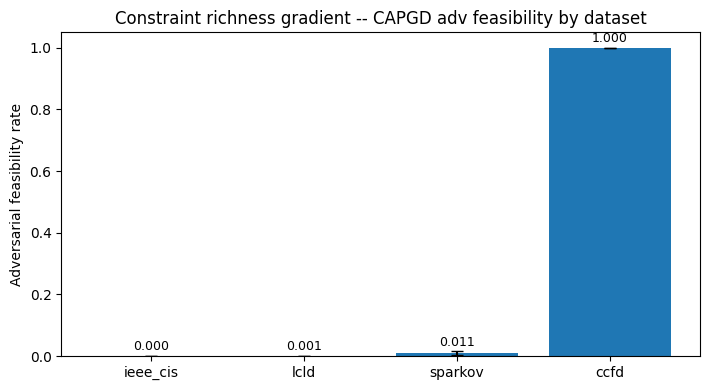

Saved gradient plot -> results/adv_examples/cross_dataset_feasibility/gradient.png


In [11]:
# Cell 15: Backup to Drive + quick gradient plot
import shutil
import matplotlib.pyplot as plt

DRIVE_OUT = "/content/drive/MyDrive/FraudBench/results/adv_examples/cross_dataset_feasibility"
os.makedirs(DRIVE_OUT, exist_ok=True)
for f in sorted(os.listdir(OUT_DIR)):
    shutil.copy(os.path.join(OUT_DIR, f), os.path.join(DRIVE_OUT, f))
print(f"Backed up {len(os.listdir(OUT_DIR))} files -> {DRIVE_OUT}")

fig, ax = plt.subplots(figsize=(7.2, 4.0))
x = np.arange(len(agg))
ax.bar(x, agg["adv_feas_mean"], yerr=agg["adv_feas_std"].fillna(0), capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(agg["dataset"])
ax.set_ylabel("Adversarial feasibility rate")
ax.set_title("Constraint richness gradient -- CAPGD adv feasibility by dataset")
ax.set_ylim(0, 1.05)
for i, v in enumerate(agg["adv_feas_mean"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "gradient.png")
plt.savefig(fig_path, dpi=150)
shutil.copy(fig_path, os.path.join(DRIVE_OUT, "gradient.png"))
plt.show()
print(f"Saved gradient plot -> {fig_path}")
